<a href="https://colab.research.google.com/github/tracehunter95/TRACE---HUNTER/blob/main/PROJECT-WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WELCOME TO THE NOTEBOOK HERE WE ARE GONNA BUILD OUR PROJECT!!!!!!

In [ ]:
import zipfile
import os

# Define the path to the original .keras model file in Google Drive
model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"

# Define the path for the zipped model file, also in Google Drive
zipped_model_path = "/content/drive/MyDrive/BE_Project/models/best_model.zip"

# Ensure the directory exists (it should, as the model is already there)
output_dir = os.path.dirname(zipped_model_path)
os.makedirs(output_dir, exist_ok=True)
system .ou.println("")

# Verify model exists before zipping
if os.path.exists(model_path):
    print(f"Model found at: {model_path}")

    # Create a zip file containing the .keras model
    with zipfile.ZipFile(zipped_model_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Add the model to the zip file, keeping its base filename
        zipf.write(model_path, os.path.basename(model_path))
    print(f"Model successfully zipped as {zipped_model_path}")
else:
    print(f"Error: Model not found at {model_path}. Please check the path.")

In [ ]:
from google.colab import drive
import os

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Google Drive is already mounted.')

Mounted at /content/drive


In [ ]:
import zipfile

model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"
zipped_model_name = "best_model.zip"

# Verify model exists
if os.path.exists(model_path):
    print(f"Model found at: {model_path}")

    # Create a zip file
    with zipfile.ZipFile(zipped_model_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(model_path, os.path.basename(model_path))
    print(f"Model successfully zipped as {zipped_model_name}")
else:
    print(f"Error: Model not found at {model_path}. Please check the path.")

Model found at: /content/drive/MyDrive/BE_Project/models/best_model.keras
Model successfully zipped as best_model.zip


In [ ]:
from google.colab import files

zipped_model_name = "best_model.zip" # Make sure this matches the name used in the previous cell

if os.path.exists(zipped_model_name):
    print("Initiating download...")
    files.download(zipped_model_name)
else:
    print(f"Error: Zipped model '{zipped_model_name}' not found. Please ensure the previous steps ran successfully.")

Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Instructions to save the model locally:

1.  **After the download initiates in your browser,** save the `best_model.zip` file.
2.  **Navigate to your desired local directory:**
    `C:\Users\durdh\LocalDesktop\BE_Project\models\`
3.  **Unzip** the `best_model.zip` file in this folder.
4.  You should then find `best_model.keras` in your `C:\Users\durdh\LocalDesktop\BE_Project\models\` directory.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import os, zipfile

# Mount your drive (you already did this)
drive.mount('/content/drive')

# Define your paths
zip_path = '/content/drive/MyDrive/BE_Project/datasets/csvs_and_zip/csvs_zip.zip'
extract_path = '/content/drive/MyDrive/BE_Project/datasets/csvs'

# Extract the files (only first time)
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extracted all CSVs successfully!")
else:
    print("Dataset already extracted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted all CSVs successfully!


In [ ]:
import os
# Check files in your extracted dataset folder
path = '/content/drive/MyDrive/BE_Project/datasets/csvs_and_zip/csvs'
print("Files inside csvs folder:\n")
print(os.listdir(path)[:50])  # shows first 20 files or folders


Files inside csvs folder:

['www.adobe.com', 'www.airbnb.com', 'www.amazon.com', 'www.apple.com', 'www.bbc.com', 'www.bing.com', 'www.blogger.com', 'www.booking.com', 'www.cnn.com', 'www.dropbox.com', 'www.espn.com', 'www.facebook.com', 'www.github.com', 'www.google.com', 'www.imdb.com', 'www.instagram.com', 'www.linkedin.com', 'www.medium.com', 'www.microsoft.com', 'www.netflix.com', 'www.nytimes.com', 'www.office.com', 'www.pinterest.com', 'www.quora.com', 'www.reddit.com', 'www.salesforce.com', 'www.stackoverflow.com', 'www.tripadvisor.com', 'www.twitch.tv', 'www.twitter.com', 'www.wikipedia.org', 'www.wordpress.com', 'www.yahoo.com', 'www.youtube.com']


In [ ]:
import pandas as pd

sample_file = '/content/drive/MyDrive/BE_Project/datasets/csvs_and_zip/csvs/www.adobe.com/www.adobe.com_run0_1760107957.csv'
df = pd.read_csv(sample_file)
print(df.columns[:10])


Index(['frame.number', 'frame.time_epoch', 'frame.len', 'tcp.srcport',
       'tcp.dstport', 'udp.srcport', 'udp.dstport', '_ws.col.protocol',
       'direction'],
      dtype='object')


In [ ]:
import os, glob, numpy as np, pandas as pd
from tqdm import tqdm

BASE = '/content/drive/MyDrive/BE_Project/datasets/csvs_and_zip/csvs'
OUT_DIR = '/content/drive/MyDrive/BE_Project/datasets/processed'
os.makedirs(OUT_DIR, exist_ok=True)
SEQ_LEN = 300            # packets per sequence
FEATURES = FEATURES = ['frame.len', 'direction', 'iat']  # features used for model

# synthetic attack parameters
JITTER_STD = 0.05       # seconds
PAD_PROB = 0.05         # fraction of dummy packets to insert

def synthesize_attack_from_df(df, jitter_std=JITTER_STD, pad_prob=PAD_PROB):
    """Create a synthetic attack copy of a visit DataFrame."""
    df2 = df.copy().reset_index(drop=True)
    # add jitter to timestamps if available
    if 'frame.time_epoch' in df2.columns:
        df2['frame.time_epoch'] = df2['frame.time_epoch'] + np.random.normal(0, jitter_std, size=len(df2))
    # slightly change packet sizes
    if 'frame.len' in df2.columns:
        df2['frame.len'] = (df2['frame.len'] + np.random.randint(-20, 50, size=len(df2))).clip(lower=1)
    # insert dummy packets
    n_dummy = int(len(df2) * pad_prob)
    if n_dummy > 0:
        dummy = df2.sample(n_dummy, replace=True).copy().reset_index(drop=True)
        if 'frame.len' in dummy.columns:
            dummy['frame.len'] = np.random.randint(60, 1500, size=n_dummy)
        if 'direction' in dummy.columns:
            dummy['direction'] = np.random.choice([0,1,-1], size=n_dummy)
        if 'frame.time_epoch' in dummy.columns:
            dummy['frame.time_epoch'] = dummy['frame.time_epoch'] + np.random.uniform(0.0001, 0.5, size=n_dummy)
        df2 = pd.concat([df2, dummy], ignore_index=True).sort_values(by='frame.time_epoch').reset_index(drop=True)
    df2['traffic_type'] = 'attack'
    return df2

def make_sequences_from_df(df, seq_len=SEQ_LEN, features=FEATURES):
    """Turn a visit dataframe into non-overlapping sequences (seq_len x features).
       Returns (X_seq, y_seq) where y_seq is numeric 0(normal)/1(attack).
    """
    df = df.copy()

    # ensure required columns exist
    for c in features:
        if c not in df.columns:
            df[c] = 0

    # compute inter-arrival time (IAT)
    if 'frame.time_epoch' in df.columns:
        df['iat'] = df['frame.time_epoch'].diff().fillna(0)
        df['iat'] = df['iat'].clip(lower=0)  # ensure non-negative
    else:
        df['iat'] = 0

    # drop unnecessary columns and fill NaNs
    arr = df[features].fillna(0).values.astype(np.float32)

    n_seqs = len(arr) // seq_len
    if n_seqs == 0:
        return np.empty((0, seq_len, len(features)), dtype=np.float32), np.empty((0,), dtype=np.int8)

    arr = arr[:n_seqs * seq_len].reshape(n_seqs, seq_len, len(features))

    # label each sequence (0=normal, 1=attack)
    labels = []
    for i in range(n_seqs):
        chunk_tt = df['traffic_type'].iloc[i * seq_len:(i + 1) * seq_len].mode()
        tt = chunk_tt.iloc[0] if len(chunk_tt) > 0 else 'normal'
        labels.append(0 if tt == 'normal' else 1)

    return arr, np.array(labels, dtype=np.int8)


In [ ]:
import os
print("Files in processed folder:")
print(os.listdir(OUT_DIR))


Files in processed folder:
[]


In [ ]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm

# BASE and OUT_DIR are already defined in previous cells
# synthesize_attack_from_df and make_sequences_from_df are also defined in previous cells

all_processed_dfs = []

# Loop through each website directory in the BASE path
for website_dir_name in tqdm(os.listdir(BASE), desc="Processing websites"):
    website_path = os.path.join(BASE, website_dir_name)

    if os.path.isdir(website_path):
        # Extract a clean label from the directory name (e.g., 'www.adobe.com' -> 'adobe')
        website_label = website_dir_name.replace("www.", "").split('.')[0]

        # Iterate over all CSV files within the website's directory
        for csv_file_path in glob.glob(os.path.join(website_path, '*.csv')):
            try:
                # Read the original (normal) traffic data for this file
                df_normal = pd.read_csv(csv_file_path)

                # Add 'traffic_type' and 'label' columns for the normal data
                df_normal['traffic_type'] = 'normal'
                df_normal['label'] = website_label

                # Create an attack version using the existing synthesize_attack_from_df function
                df_attack = synthesize_attack_from_df(df_normal.copy())
                # Ensure 'label' is carried over to the attack data
                df_attack['label'] = website_label

                # Append both normal and attack dataframes to the list
                all_processed_dfs.append(df_normal)
                all_processed_dfs.append(df_attack)

            except Exception as e:
                print(f"Skipping {csv_file_path} due to error: {e}")

# Concatenate all processed dataframes into combined_final if there's data
if all_processed_dfs:
    combined_final = pd.concat(all_processed_dfs, ignore_index=True)
    print(" Combined final dataset created with normal and synthetic attack traffic.")
    print("\nTraffic type distribution:")
    print(combined_final['traffic_type'].value_counts())
    print("\nFirst 5 rows of combined_final:")
    print(combined_final.head())

    # Save the combined_final DataFrame to the processed folder
    output_path = os.path.join(OUT_DIR, "combined_final.csv")
    combined_final.to_csv(output_path, index=False)
    print(f"\n Saved combined_final.csv to: {output_path}")
    print("Files currently in processed folder:")
    print(os.listdir(OUT_DIR))
else:
    print("No data was processed. combined_final DataFrame was not created.")


Processing websites: 100%|██████████| 34/34 [03:33<00:00,  6.29s/it]


✅ Combined final dataset created with normal and synthetic attack traffic.

Traffic type distribution:
traffic_type
attack    11334474
normal    10795051
Name: count, dtype: int64

First 5 rows of combined_final:
   frame.number  frame.time_epoch  frame.len tcp.srcport tcp.dstport  \
0             1      1.760108e+09       1444        80.0     54783.0   
1             2      1.760108e+09       1404        80.0     58757.0   
2             3      1.760108e+09       1444        80.0     61828.0   
3             4      1.760108e+09       1444        80.0     61843.0   
4             5      1.760108e+09       1444        80.0     61843.0   

   udp.srcport  udp.dstport _ws.col.protocol  direction traffic_type  label  
0          NaN          NaN              TCP          0       normal  adobe  
1          NaN          NaN              TCP         -1       normal  adobe  
2          NaN          NaN              TCP          0       normal  adobe  
3          NaN          NaN              T

In [ ]:
import pandas as pd

combined_final = pd.read_csv('/content/drive/MyDrive/BE_Project/datasets/processed/combined_final.csv')
print(combined_final.head())

/tmp/ipython-input-2720400328.py:3: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_final = pd.read_csv('/content/drive/MyDrive/BE_Project/datasets/processed/combined_final.csv')


   frame.number  frame.time_epoch  frame.len tcp.srcport tcp.dstport  \
0             1      1.760108e+09       1444        80.0     54783.0   
1             2      1.760108e+09       1404        80.0     58757.0   
2             3      1.760108e+09       1444        80.0     61828.0   
3             4      1.760108e+09       1444        80.0     61843.0   
4             5      1.760108e+09       1444        80.0     61843.0   

   udp.srcport  udp.dstport _ws.col.protocol  direction traffic_type  label  
0          NaN          NaN              TCP          0       normal  adobe  
1          NaN          NaN              TCP         -1       normal  adobe  
2          NaN          NaN              TCP          0       normal  adobe  
3          NaN          NaN              TCP          0       normal  adobe  
4          NaN          NaN              TCP          0       normal  adobe  


In [ ]:
print("Website labels:", combined_final['label'].unique()[:10])  # show first 10
print("Total websites:", combined_final['label'].nunique())

Website labels: ['adobe' 'airbnb' 'amazon' 'apple' 'bbc' 'bing' 'blogger' 'booking' 'cnn'
 'dropbox']
Total websites: 34


In [ ]:
print("\nTraffic type distribution:")
print(combined_final['traffic_type'].value_counts())


Traffic type distribution:
traffic_type
attack    11334474
normal    10795051
Name: count, dtype: int64


In [ ]:
print("\nMissing values per column:")
print(combined_final.isnull().sum())


Missing values per column:
frame.number               0
frame.time_epoch           0
frame.len                  0
tcp.srcport          5029228
tcp.dstport          5029228
udp.srcport         17101279
udp.dstport         17101279
_ws.col.protocol           0
direction                  0
traffic_type               0
label                      0
dtype: int64


In [ ]:
combined_final[['frame.len', 'direction', 'label', 'traffic_type']].head(100)

,frame.len,direction,label,traffic_type
0,1444,0,adobe,normal
1,1404,-1,adobe,normal
2,1444,0,adobe,normal
3,1444,0,adobe,normal
4,1444,0,adobe,normal
...,...,...,...,...
95,1444,0,adobe,normal
96,1444,0,adobe,normal
97,1444,0,adobe,normal
98,1444,0,adobe,normal


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/BE_Project/datasets/processed/combined_final.csv')
print(df.head())

/tmp/ipython-input-486929002.py:2: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/BE_Project/datasets/processed/combined_final.csv')


   frame.number  frame.time_epoch  frame.len tcp.srcport tcp.dstport  \
0             1      1.760108e+09       1444        80.0     54783.0   
1             2      1.760108e+09       1404        80.0     58757.0   
2             3      1.760108e+09       1444        80.0     61828.0   
3             4      1.760108e+09       1444        80.0     61843.0   
4             5      1.760108e+09       1444        80.0     61843.0   

   udp.srcport  udp.dstport _ws.col.protocol  direction traffic_type  label  
0          NaN          NaN              TCP          0       normal  adobe  
1          NaN          NaN              TCP         -1       normal  adobe  
2          NaN          NaN              TCP          0       normal  adobe  
3          NaN          NaN              TCP          0       normal  adobe  
4          NaN          NaN              TCP          0       normal  adobe  


In [ ]:
# total counts of each class
print(combined_final['traffic_type'].value_counts())

traffic_type
attack    11334474
normal    10795051
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

dataset_path = '/content/drive/MyDrive/BE_Project/datasets/processed/combined_final.csv'

# Loading the dataset
df = pd.read_csv(dataset_path)
print("Dataset shape:", df.shape)
print(df.head())


In [ ]:
# Select numeric features for training
features = ['frame.len', 'direction', 'frame.time_epoch']

# Initialize MinMaxScaler to scale features between 0 and 1
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

print("Normalized feature preview:")
print(df[features].head())

# Check unique labels and traffic types
print("\nUnique website labels:", df['label'].nunique())
print("Unique traffic types:", df['traffic_type'].unique())


In [ ]:
normalized_path = '/content/drive/MyDrive/BE_Project/datasets/processed/combined_final_normalized.csv'
df.to_csv(normalized_path, index=False)
print(f"\n Normalized dataset saved to: {normalized_path}")



✅ Normalized dataset saved to: /content/drive/MyDrive/BE_Project/datasets/processed/combined_final_normalized.csv


In [ ]:
import pandas as pd

# Loading normalized dataset
normalized_path = "/content/drive/MyDrive/BE_Project/datasets/processed/combined_final_normalized.csv"
normalized_df = pd.read_csv(normalized_path)

print(normalized_df.head())
print("\nColumns:", normalized_df.columns.tolist())
print("\nTraffic types:", normalized_df['traffic_type'].unique())


/tmp/ipython-input-2385274772.py:5: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  normalized_df = pd.read_csv(normalized_path)


   frame.number  frame.time_epoch  frame.len tcp.srcport tcp.dstport  \
0             1          0.800008   0.021746        80.0     54783.0   
1             2          0.800008   0.021129        80.0     58757.0   
2             3          0.800008   0.021746        80.0     61828.0   
3             4          0.800008   0.021746        80.0     61843.0   
4             5          0.800008   0.021746        80.0     61843.0   

   udp.srcport  udp.dstport _ws.col.protocol  direction traffic_type  label  
0          NaN          NaN              TCP        0.5       normal  adobe  
1          NaN          NaN              TCP        0.0       normal  adobe  
2          NaN          NaN              TCP        0.5       normal  adobe  
3          NaN          NaN              TCP        0.5       normal  adobe  
4          NaN          NaN              TCP        0.5       normal  adobe  

Columns: ['frame.number', 'frame.time_epoch', 'frame.len', 'tcp.srcport', 'tcp.dstport', 'udp.srcp

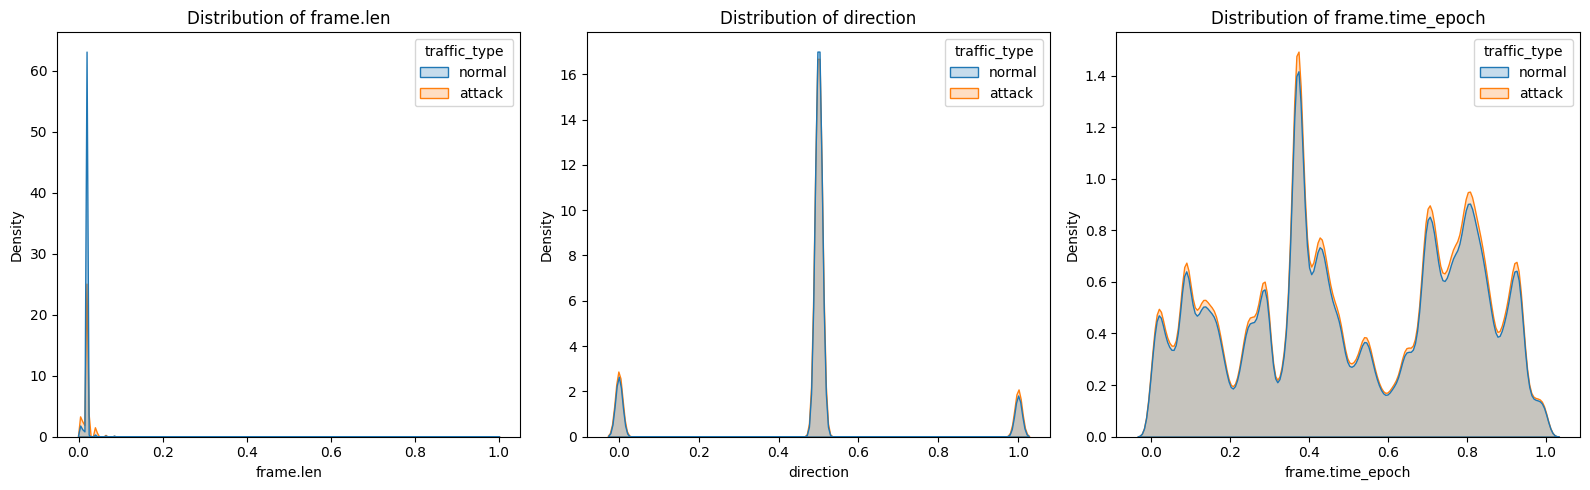

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot feature distributions by traffic type
plt.figure(figsize=(16, 5))
for i, col in enumerate(['frame.len', 'direction', 'frame.time_epoch']):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=normalized_df, x=col, hue='traffic_type', fill=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


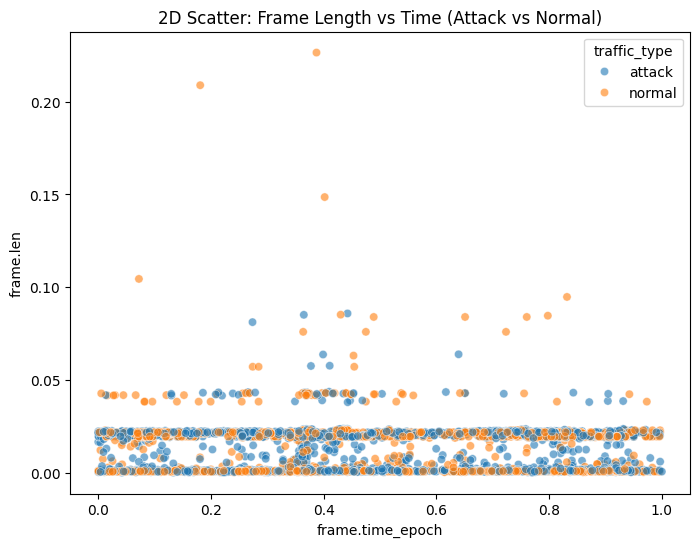

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=normalized_df.sample(5000, random_state=42),  # sample for clarity
    x='frame.time_epoch',
    y='frame.len',
    hue='traffic_type',
    alpha=0.6
)
plt.title("2D Scatter: Frame Length vs Time (Attack vs Normal)")
plt.show()


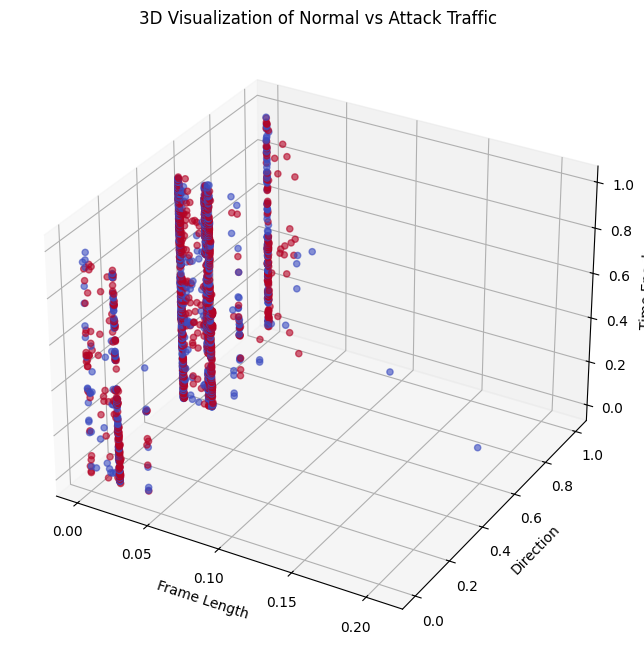

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

sample_df = normalized_df.sample(3000, random_state=42)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    sample_df['frame.len'],
    sample_df['direction'],
    sample_df['frame.time_epoch'],
    c=sample_df['traffic_type'].map({'normal':0, 'attack':1}),
    cmap='coolwarm', alpha=0.6
)
ax.set_xlabel('Frame Length')
ax.set_ylabel('Direction')
ax.set_zlabel('Time Epoch')
plt.title("3D Visualization of Normal vs Attack Traffic")
plt.show()


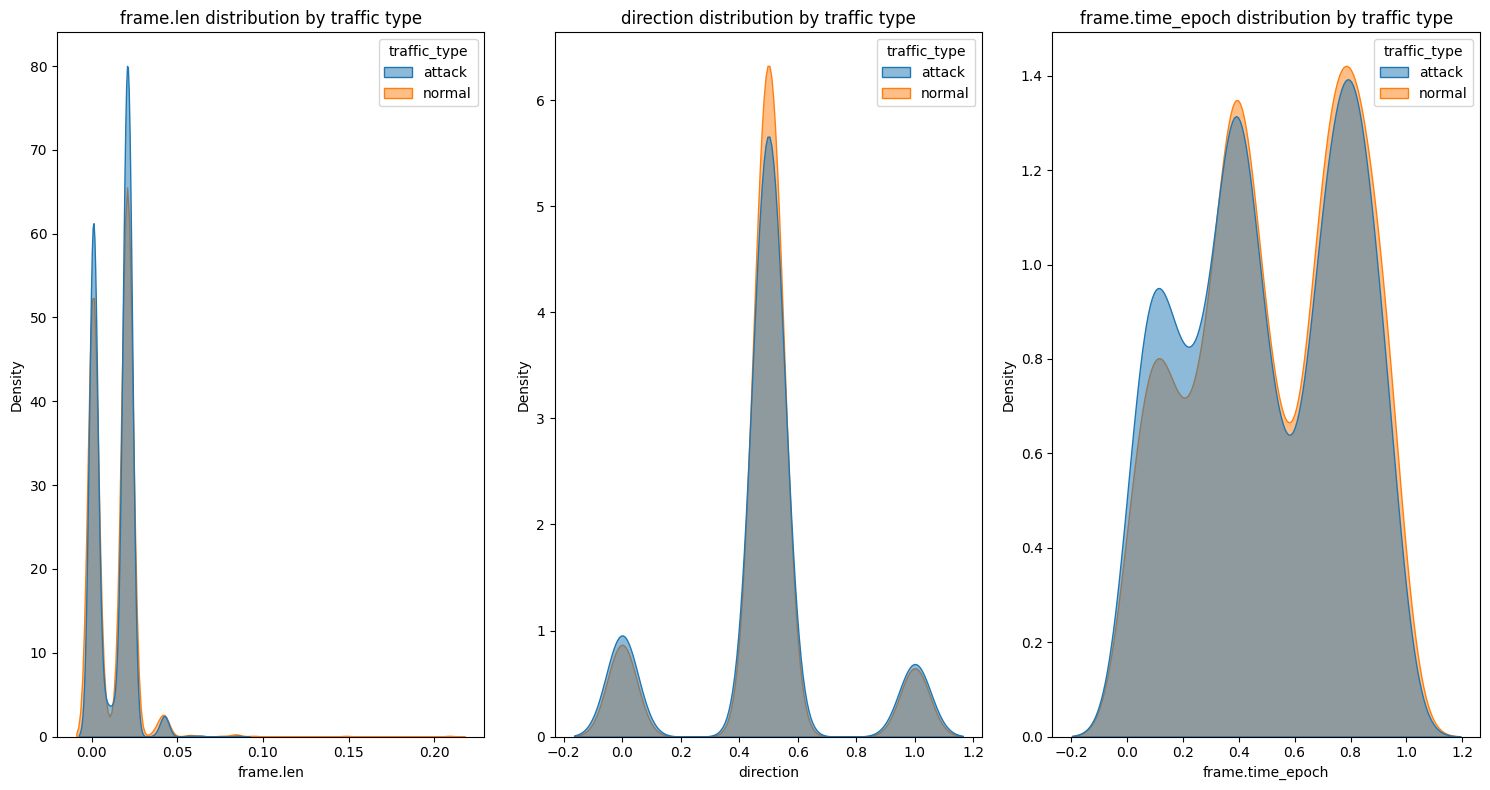

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = ['frame.len', 'direction', 'frame.time_epoch']

plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_features):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=sample_df, x=feature, hue='traffic_type', fill=True, common_norm=False, alpha=0.5)
    plt.title(f"{feature} distribution by traffic type")
    plt.xlabel(feature)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()


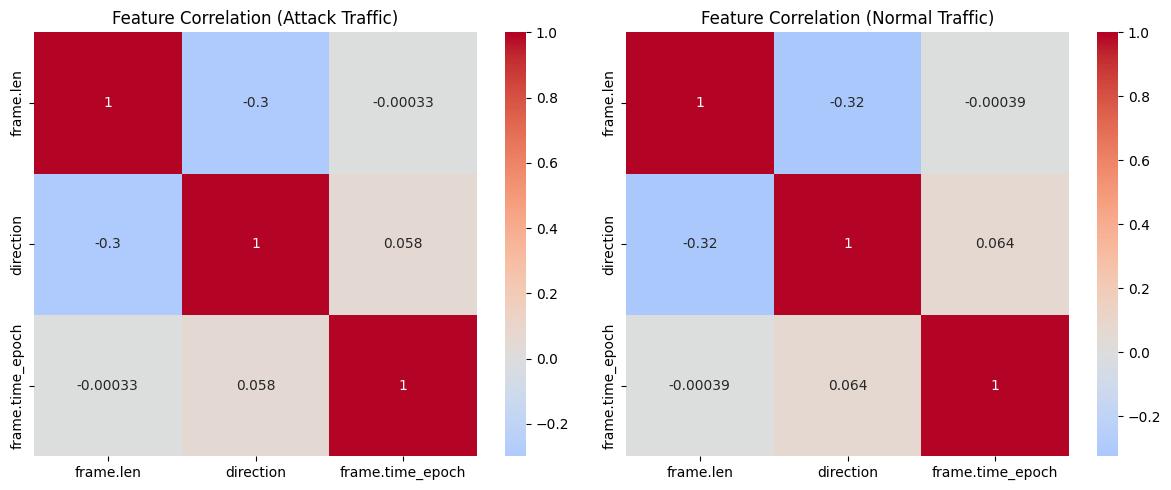

In [ ]:
import numpy as np

plt.figure(figsize=(12, 5))

# Attack traffic correlation
plt.subplot(1, 2, 1)
corr_attack = normalized_df[normalized_df['traffic_type'] == 'attack'][numeric_features].corr()
sns.heatmap(corr_attack, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation (Attack Traffic)")

# Normal traffic correlation
plt.subplot(1, 2, 2)
corr_normal = normalized_df[normalized_df['traffic_type'] == 'normal'][numeric_features].corr()
sns.heatmap(corr_normal, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation (Normal Traffic)")

plt.tight_layout()
plt.show()


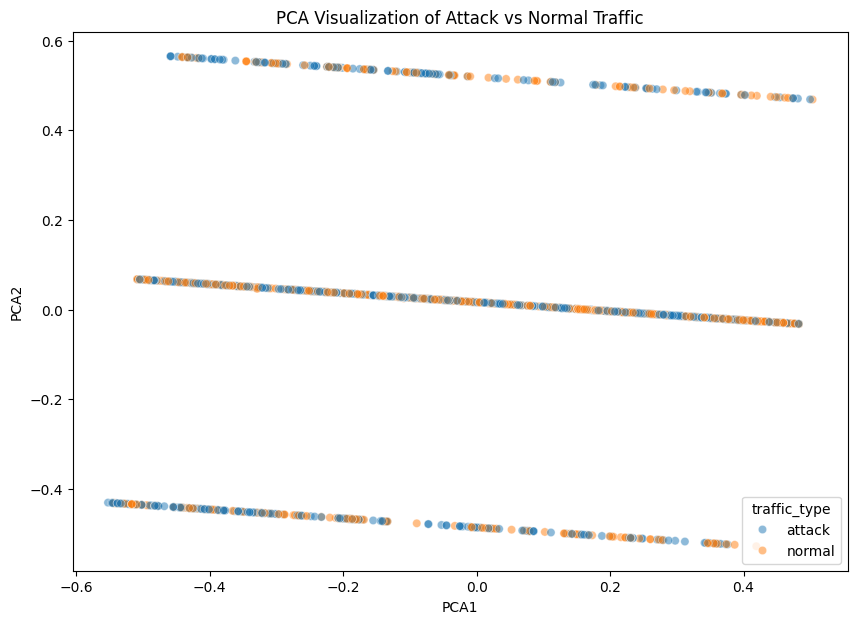

In [ ]:
from sklearn.decomposition import PCA

# Select numeric features for PCA
features = ['frame.len', 'direction', 'frame.time_epoch']
pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_df[features])

# Add PCA results back to the dataframe
sample_df['PCA1'], sample_df['PCA2'] = pca_result[:,0], pca_result[:,1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=sample_df, x='PCA1', y='PCA2', hue='traffic_type', alpha=0.5)
plt.title("PCA Visualization of Attack vs Normal Traffic")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


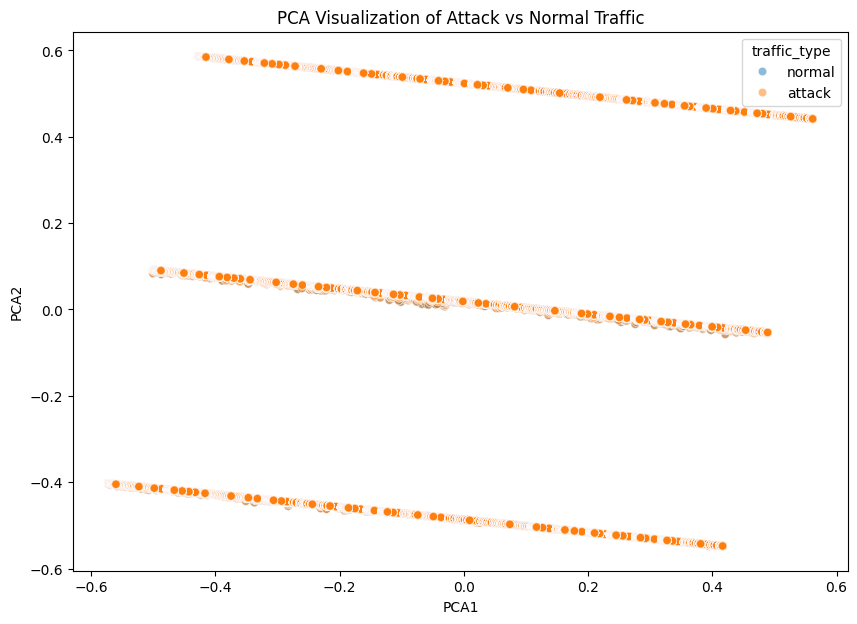

In [ ]:
from sklearn.decomposition import PCA

# Select numeric features for PCA
features = ['frame.len', 'direction', 'frame.time_epoch']
pca = PCA(n_components=2)
pca_result = pca.fit_transform(normalized_df[features])

# Add PCA results back to the dataframe
normalized_df['PCA1'], normalized_df['PCA2'] = pca_result[:,0], pca_result[:,1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=normalized_df, x='PCA1', y='PCA2', hue='traffic_type', alpha=0.5)
plt.title("PCA Visualization of Attack vs Normal Traffic")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences

df = pd.read_csv('/content/drive/MyDrive/BE_Project/datasets/processed/combined_final_normalized.csv')

# Choose features for sequence
FEATURES = ['frame.len', 'direction', 'frame.time_epoch']

# Group data by website label
grouped = df.groupby(['label', 'traffic_type'])

X_sequences = []
y_labels = []
y_traffic = []

# Define sequence length (number of packets per sequence)
SEQ_LEN = 100

for (label, traffic_type), group in grouped:
    data = group[FEATURES].values

    # Break large groups into multiple sequences of SEQ_LEN
    for i in range(0, len(data), SEQ_LEN):
        seq = data[i:i+SEQ_LEN]
        if len(seq) < SEQ_LEN:
            seq = pad_sequences([seq], maxlen=SEQ_LEN, dtype='float32', padding='post', truncating='post')[0]
        X_sequences.append(seq)
        y_labels.append(label)
        y_traffic.append(traffic_type)

# Convert to numpy arrays
X = np.array(X_sequences)
print("Shape of X:", X.shape)

# Encode categorical outputs
le_label = LabelEncoder()
le_traffic = LabelEncoder()

y_label_encoded = le_label.fit_transform(y_labels)
y_traffic_encoded = le_traffic.fit_transform(y_traffic)

print("Label classes:", le_label.classes_)
print("Traffic classes:", le_traffic.classes_)


/tmp/ipython-input-370225543.py:6: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/BE_Project/datasets/processed/combined_final_normalized.csv')


Shape of X: (221330, 100, 3)
Label classes: ['adobe' 'airbnb' 'amazon' 'apple' 'bbc' 'bing' 'blogger' 'booking' 'cnn'
 'dropbox' 'espn' 'facebook' 'github' 'google' 'imdb' 'instagram'
 'linkedin' 'medium' 'microsoft' 'netflix' 'nytimes' 'office' 'pinterest'
 'quora' 'reddit' 'salesforce' 'stackoverflow' 'tripadvisor' 'twitch'
 'twitter' 'wikipedia' 'wordpress' 'yahoo' 'youtube']
Traffic classes: ['attack' 'normal']


In [ ]:
from sklearn.model_selection import train_test_split

# Spliting dataset into training and testing sets
X_train, X_test, y_train_label, y_test_label, y_train_traffic, y_test_traffic = train_test_split(
    X, y_label_encoded, y_traffic_encoded,
    test_size=0.2,        # 80-20 split
    random_state=42,
    stratify=y_label_encoded
)

# Ensuring traffic labels are 1D integers
y_train_traffic = np.array(y_train_traffic).reshape(-1).astype(int)
y_test_traffic  = np.array(y_test_traffic).reshape(-1).astype(int)

print("Shapes after split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train_label:", y_train_label.shape)
print("y_train_traffic:", y_train_traffic.shape)



Shapes after split:
X_train: (177064, 100, 3)
X_test: (44266, 100, 3)
y_train_label: (177064,)
y_train_traffic: (177064,)


In [ ]:
import numpy as np

# Check traffic type distribution in train and test sets
unique, counts = np.unique(y_train_traffic, return_counts=True)
print("Train traffic distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test_traffic, return_counts=True)
print("Test traffic distribution:", dict(zip(unique, counts)))


Train traffic distribution: {np.int64(0): np.int64(90701), np.int64(1): np.int64(86363)}
Test traffic distribution: {np.int64(0): np.int64(22661), np.int64(1): np.int64(21605)}


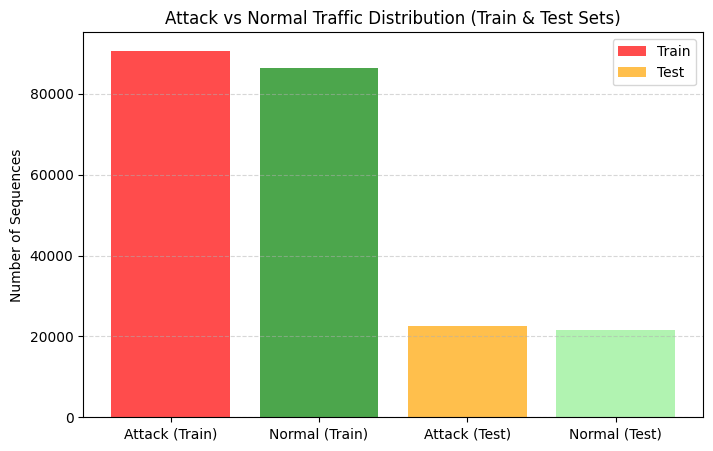

In [ ]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(8,5))

# Plot training distribution
plt.bar(['Attack (Train)', 'Normal (Train)'],
        [90690, 86374],
        color=['red', 'green'], alpha=0.7, label='Train')

# Plot testing distribution
plt.bar(['Attack (Test)', 'Normal (Test)'],
        [22672, 21594],
        color=['orange', 'lightgreen'], alpha=0.7, label='Test')

# Add labels and title
plt.title("Attack vs Normal Traffic Distribution (Train & Test Sets)")
plt.ylabel("Number of Sequences")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Attention mechanism
def attention_block(inputs):
    attention = layers.Dense(1, activation='tanh')(inputs)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(inputs.shape[-1])(attention)
    attention = layers.Permute([2, 1])(attention)
    output = layers.Multiply()([inputs, attention])
    return output

# Model architecture
def build_cnn_bilstm_attention(input_shape):
    inputs = layers.Input(shape=input_shape)

    # CNN block
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # BiLSTM block
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # Attention
    x = attention_block(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    # Output 1: Website label
    out_label = layers.Dense(len(le_label.classes_), activation='softmax', name='website_output')(x)

    # Output 2: Traffic type (attack/normal)
    out_traffic = layers.Dense(len(le_traffic.classes_), activation='softmax', name='traffic_output')(x)

    model = models.Model(inputs=inputs, outputs=[out_label, out_traffic])
    model.compile(
        optimizer='adam',
        loss={'website_output': 'sparse_categorical_crossentropy',
              'traffic_output': 'sparse_categorical_crossentropy'},
        metrics=['accuracy']
    )

    return model

model = build_cnn_bilstm_attention(X_train.shape[1:])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 64)   │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 50, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │     66,048 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 1)     │        129 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 50)   │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 50, 128)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50, 128)   │          0 │ bidirectional[0]… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 6400)      │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    819,328 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ website_output      │ (None, 34)        │      4,386 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ traffic_output      │ (None, 2)         │        258 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 890,789 (3.40 MB)

 Trainable params: 890,789 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss={
        "website_output": "sparse_categorical_crossentropy",
        "traffic_output": "sparse_categorical_crossentropy",
    },
    metrics={
        "website_output": "accuracy",
        "traffic_output": "accuracy",
    }
)


In [ ]:
# setting up training call backs
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]


In [ ]:
# Training for 30 epochs with an 80-20 train-validation split.
history = model.fit(
    X_train,
    {"website_output": y_train_label, "traffic_output": y_train_traffic},
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5888 - traffic_output_accuracy: 0.5033 - traffic_output_loss: 0.7071 - website_output_accuracy: 0.3679 - website_output_loss: 1.8817

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - loss: 2.5885 - traffic_output_accuracy: 0.5033 - traffic_output_loss: 0.7071 - website_output_accuracy: 0.3680 - website_output_loss: 1.8814 - val_loss: 1.0978 - val_traffic_output_accuracy: 0.5100 - val_traffic_output_loss: 0.6943 - val_website_output_accuracy: 0.8684 - val_website_output_loss: 0.4035 - learning_rate: 5.0000e-04
Epoch 2/30
2211/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1944 - traffic_output_accuracy: 0.5036 - traffic_output_loss: 0.6953 - website_output_accuracy: 0.8026 - website_output_loss: 0.4990

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 1.1943 - traffic_output_accuracy: 0.5036 - traffic_output_loss: 0.6953 - website_output_accuracy: 0.8026 - website_output_loss: 0.4989 - val_loss: 0.9721 - val_traffic_output_accuracy: 0.4920 - val_traffic_output_loss: 0.6996 - val_website_output_accuracy: 0.9029 - val_website_output_loss: 0.2725 - learning_rate: 5.0000e-04
Epoch 3/30
2211/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1050 - traffic_output_accuracy: 0.5023 - traffic_output_loss: 0.6952 - website_output_accuracy: 0.8365 - website_output_loss: 0.4098

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - loss: 1.1050 - traffic_output_accuracy: 0.5023 - traffic_output_loss: 0.6952 - website_output_accuracy: 0.8365 - website_output_loss: 0.4098 - val_loss: 0.9421 - val_traffic_output_accuracy: 0.4892 - val_traffic_output_loss: 0.6951 - val_website_output_accuracy: 0.9043 - val_website_output_loss: 0.2470 - learning_rate: 5.0000e-04
Epoch 4/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0645 - traffic_output_accuracy: 0.5018 - traffic_output_loss: 0.6949 - website_output_accuracy: 0.8527 - website_output_loss: 0.3696

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 1.0645 - traffic_output_accuracy: 0.5018 - traffic_output_loss: 0.6949 - website_output_accuracy: 0.8527 - website_output_loss: 0.3696 - val_loss: 0.9170 - val_traffic_output_accuracy: 0.4967 - val_traffic_output_loss: 0.6936 - val_website_output_accuracy: 0.9218 - val_website_output_loss: 0.2234 - learning_rate: 5.0000e-04
Epoch 5/30
2213/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0316 - traffic_output_accuracy: 0.5041 - traffic_output_loss: 0.6948 - website_output_accuracy: 0.8645 - website_output_loss: 0.3367

...

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 0.8673 - traffic_output_accuracy: 0.5042 - traffic_output_loss: 0.6938 - website_output_accuracy: 0.9315 - website_output_loss: 0.1735 - val_loss: 0.8158 - val_traffic_output_accuracy: 0.5039 - val_traffic_output_loss: 0.6933 - val_website_output_accuracy: 0.9513 - val_website_output_loss: 0.1225 - learning_rate: 2.5000e-04
Epoch 19/30
2211/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8796 - traffic_output_accuracy: 0.5068 - traffic_output_loss: 0.6937 - website_output_accuracy: 0.9250 - website_output_loss: 0.1860

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 0.8796 - traffic_output_accuracy: 0.5068 - traffic_output_loss: 0.6937 - website_output_accuracy: 0.9250 - website_output_loss: 0.1860 - val_loss: 0.8053 - val_traffic_output_accuracy: 0.5130 - val_traffic_output_loss: 0.6933 - val_website_output_accuracy: 0.9548 - val_website_output_loss: 0.1120 - learning_rate: 2.5000e-04
Epoch 20/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - loss: 0.8750 - traffic_output_accuracy: 0.5109 - traffic_output_loss: 0.6935 - website_output_accuracy: 0.9290 - website_output_loss: 0.1815 - val_loss: 0.8357 - val_traffic_output_accuracy: 0.5046 - val_traffic_output_loss: 0.6931 - val_website_output_accuracy: 0.9358 - val_website_output_loss: 0.1428 - learning_rate: 2.5000e-04
Epoch 21/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.8582 - traffic_output_accuracy: 0.5103 - traffic_output_loss: 0.6934 - website_output_accuracy: 0.9361 - website_output_loss: 0.1649 - val_loss: 0.8445 - val_traff

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.8219 - traffic_output_accuracy: 0.5135 - traffic_output_loss: 0.6928 - website_output_accuracy: 0.9505 - website_output_loss: 0.1291 - val_loss: 0.7813 - val_traffic_output_accuracy: 0.5211 - val_traffic_output_loss: 0.6923 - val_website_output_accuracy: 0.9638 - val_website_output_loss: 0.0892 - learning_rate: 1.2500e-04
Epoch 24/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.8218 - traffic_output_accuracy: 0.5123 - traffic_output_loss: 0.6928 - website_output_accuracy: 0.9490 - website_output_loss: 0.1290 - val_loss: 0.8742 - val_traffic_output_accuracy: 0.5377 - val_traffic_output_loss: 0.6914 - val_website_output_accuracy: 0.9221 - val_website_output_loss: 0.1826 - learning_rate: 1.2500e-04
Epoch 25/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.8125 - traffic_output_accuracy: 0.5163 - traffic_output_loss: 0.6924 - website_output_accuracy: 0.9544 - website_output_loss: 0.1202 - val_loss: 0.8461 - val_traff

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.8146 - traffic_output_accuracy: 0.5211 - traffic_output_loss: 0.6915 - website_output_accuracy: 0.9517 - website_output_loss: 0.1231 - val_loss: 0.7770 - val_traffic_output_accuracy: 0.5441 - val_traffic_output_loss: 0.6882 - val_website_output_accuracy: 0.9637 - val_website_output_loss: 0.0888 - learning_rate: 1.2500e-04
Epoch 27/30
2210/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8116 - traffic_output_accuracy: 0.5332 - traffic_output_loss: 0.6880 - website_output_accuracy: 0.9524 - website_output_loss: 0.1237

2214/2214 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 0.8116 - traffic_output_accuracy: 0.5332 - traffic_output_loss: 0.6880 - website_output_accuracy: 0.9524 - website_output_loss: 0.1236 - val_loss: 0.7629 - val_traffic_output_accuracy: 0.5707 - val_traffic_output_loss: 0.6813 - val_website_output_accuracy: 0.9657 - val_website_output_loss: 0.0816 - learning_rate: 1.2500e-04
Epoch 28/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 0.8052 - traffic_output_accuracy: 0.5461 - traffic_output_loss: 0.6834 - website_output_accuracy: 0.9535 - website_output_loss: 0.1217 - val_loss: 0.8689 - val_traffic_output_accuracy: 0.5650 - val_traffic_output_loss: 0.6792 - val_website_output_accuracy: 0.9189 - val_website_output_loss: 0.1895 - learning_rate: 1.2500e-04
Epoch 29/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.8020 - traffic_output_accuracy: 0.5511 - traffic_output_loss: 0.6799 - website_output_accuracy: 0.9521 - website_output_loss: 0.1221 - val_loss: 0.7913 - val_traff

In [ ]:
# Save your model
model.save("my_model.keras")



In [ ]:
from tensorflow.keras.models import load_model
model = load_model("my_model.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.save("/content/drive/MyDrive/my_model.keras")



In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor='val_traffic_output_accuracy',  # or val_loss
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

history = model.fit(
    X_train,
    {"website_output": y_train_label, "traffic_output": y_train_traffic},
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[checkpoint]  # add other callbacks
)


Epoch 1/30
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3005 - traffic_output_accuracy: 0.5326 - traffic_output_loss: 0.6894 - website_output_accuracy: 0.5408 - website_output_loss: 1.6110
Epoch 1: val_traffic_output_accuracy improved from -inf to 0.53991, saving model to /content/drive/MyDrive/best_model.keras
2214/2214 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - loss: 2.3003 - traffic_output_accuracy: 0.5326 - traffic_output_loss: 0.6894 - website_output_accuracy: 0.5408 - website_output_loss: 1.6108 - val_loss: 1.8885 - val_traffic_output_accuracy: 0.5399 - val_traffic_output_loss: 0.6962 - val_website_output_accuracy: 0.3765 - val_website_output_loss: 1.1922
Epoch 2/30
2213/2214 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.5588 - traffic_output_accuracy: 0.6092 - traffic_output_loss: 0.6560 - website_output_accuracy: 0.6431 - website_output_loss: 0.9028
Epoch 2: val_traffic_output_accuracy improved from 0.53991 to 0.66546, saving model to /content/drive/MyDrive/best_model.keras
22

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/drive/MyDrive/best_model.keras")


In [ ]:
results = best_model.evaluate(X_test, {"website_output": y_test_label, "traffic_output": y_test_traffic})
print(results)


1384/1384 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.3427 - traffic_output_accuracy: 0.9599 - traffic_output_loss: 0.1086 - website_output_accuracy: 0.9043 - website_output_loss: 0.2341
[0.34537944197654724, 0.23580317199230194, 0.10947561264038086, 0.9603984951972961, 0.904712438583374]


In [ ]:
best_model.save("/content/drive/MyDrive/final_model.keras")


In [ ]:
import os

project_folder = r"C:\Users\durdh\LocalDesktop\BE_Project"  # Update if needed

os.makedirs(project_folder, exist_ok=True)


In [ ]:
import os
import shutil

# Source paths
my_model_path = "/content/drive/MyDrive/my_model.keras"
best_model_path = "/content/drive/MyDrive/best_model.keras"
final_model_path = "/content/drive/MyDrive/final_model.keras"


dest_folder = "/content/drive/MyDrive/BE_Project/models"
os.makedirs(dest_folder, exist_ok=True)


shutil.copy(my_model_path, dest_folder)
shutil.copy(best_model_path, dest_folder)
shutil.copy(final_model_path, dest_folder)

print("All models have been copied to:", dest_folder)



All models have been copied to: /content/drive/MyDrive/BE_Project/models


In [ ]:
# Testing
from tensorflow.keras.models import load_model

# best_model
best_model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"

# Loading the model
best_model = load_model(best_model_path)


In [ ]:
print(X_test.shape)
print(y_test_label.shape, y_test_traffic.shape)


(44266, 100, 3)
(44266,) (44266,)


In [ ]:
import numpy as np

# For website labels
num_website_classes = len(np.unique(y_train_label))
print("Number of website classes:", num_website_classes)

# For traffic labels
num_traffic_classes = len(np.unique(y_train_traffic))
print("Number of traffic classes:", num_traffic_classes)


Number of website classes: 34
Number of traffic classes: 2


In [ ]:
from tensorflow.keras.utils import to_categorical

# One-hot encode test labels
y_test_label_oh = to_categorical(y_test_label, num_classes=34)
y_test_traffic_oh = to_categorical(y_test_traffic, num_classes=2)

print("y_test_label_oh shape:", y_test_label_oh.shape)
print("y_test_traffic_oh shape:", y_test_traffic_oh.shape)


y_test_label_oh shape: (44266, 34)
y_test_traffic_oh shape: (44266, 2)


In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/drive/MyDrive/BE_Project/models/best_model.keras")


In [ ]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 64)   │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 50, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │     66,048 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 1)     │        129 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 50)   │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 50, 128)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50, 128)   │          0 │ bidirectional[0]… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 6400)      │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    819,328 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ website_output      │ (None, 34)        │      4,386 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ traffic_output      │ (None, 2)         │        258 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,781,580 (6.80 MB)

 Trainable params: 890,789 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 890,791 (3.40 MB)

In [ ]:
best_model.compile(
    optimizer='adam',
    loss={
        "website_output": "categorical_crossentropy",
        "traffic_output": "categorical_crossentropy"
    },
    metrics={"website_output": "accuracy", "traffic_output": "accuracy"}
)




In [ ]:
results = best_model.evaluate(
    X_test,
    {"website_output": y_test_label_oh, "traffic_output": y_test_traffic_oh},
    batch_size=64,
    verbose=1
)
print("Test results:", results)


692/692 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3427 - traffic_output_accuracy: 0.9599 - traffic_output_loss: 0.1086 - website_output_accuracy: 0.9043 - website_output_loss: 0.2341
Test results: [0.3453793525695801, 0.23583990335464478, 0.10956276953220367, 0.9603984951972961, 0.904712438583374]


In [ ]:
import os
import numpy as np

# Path to your BE_Project folder
project_folder = "/content/drive/MyDrive/BE_Project/"

# Create a 'data' folder inside BE_Project
data_folder = os.path.join(project_folder, "data")
os.makedirs(data_folder, exist_ok=True)  # This will create the folder if it doesn't exist

# Save your test datasets
np.save(os.path.join(data_folder, "X_test.npy"), X_test)
np.save(os.path.join(data_folder, "y_test_label.npy"), y_test_label)
np.save(os.path.join(data_folder, "y_test_traffic.npy"), y_test_traffic)

print("Data folder created and test datasets saved successfully!")


Data folder created and test datasets saved successfully!


In [ ]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical


model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"

# Replace with your test dataset paths

X_test_path = "/content/drive/MyDrive/BE_Project/data/X_test.npy"
y_test_label_path = "/content/drive/MyDrive/BE_Project/data/y_test_label.npy"
y_test_traffic_path = "/content/drive/MyDrive/BE_Project/data/y_test_traffic.npy"


model = load_model(model_path)
print("Model loaded successfully!")


# Loading test data

X_test = np.load(X_test_path)
y_test_label = np.load(y_test_label_path)        # integer labels
y_test_traffic = np.load(y_test_traffic_path)    # integer labels

print("Test data shapes:")
print("X_test:", X_test.shape)
print("y_test_label:", y_test_label.shape)
print("y_test_traffic:", y_test_traffic.shape)

# Evaluating the model using integer labels
results = model.evaluate(
    X_test,
    {"website_output": y_test_label, "traffic_output": y_test_traffic},
    batch_size=64,
    verbose=1
)

print("\nTest results:")
print("Overall Loss:", results[0])
print("Website Loss:", results[1])
print("Traffic Loss:", results[2])
print("Traffic Accuracy:", results[3])
print("Website Accuracy:", results[4])


Model loaded successfully!
Test data shapes:
X_test: (44266, 100, 3)
y_test_label: (44266,)
y_test_traffic: (44266,)
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.3427 - traffic_output_accuracy: 0.9599 - traffic_output_loss: 0.1086 - website_output_accuracy: 0.9043 - website_output_loss: 0.2341

Test results:
Overall Loss: 0.3453793525695801
Website Loss: 0.23583990335464478
Traffic Loss: 0.10956276953220367
Traffic Accuracy: 0.9603984951972961
Website Accuracy: 0.904712438583374


In [ ]:
import pandas as pd

train_history = pd.DataFrame(history.history)

train_history.to_csv("/content/drive/MyDrive/BE_Project/training_testing_results/training_results.csv", index=False)
print("Training results saved successfully!")


Training results saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"
best_model = load_model(model_path)

print(f"Model loaded successfully from: {model_path}")

In [ ]:
import zipfile

model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"
zzipped_model_name = "best_model.zip"

# Verify model exists
if os.path.exists(model_path):
    print(f"Model found at: {model_path}")

    # Create a zip file
    with zipfile.ZipFile(zipped_model_name, 'w', zipfile.DEFLATED) as zipf:
        zipf.write(model_path, os.path.basename(model_path))
    print(f"Model successfully zipped as {zipped_model_name}")
else:
    print(f"Error: Model not found at {model_path}. Please check the path.")

```python
import zipfile
import os

model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"
zzipped_model_name = "best_model.zip"

# Verify model exists
if os.path.exists(model_path):
    print(f"Model found at: {model_path}")

    # Create a zip file
    with zipfile.ZipFile(zzipped_model_name, 'w', zipfile.DEFLATED) as zipf:
        zipf.write(model_path, os.path.basename(model_path))
    print(f"Model successfully zipped as {zzipped_model_name}")
else:
    print(f"Error: Model not found at {model_path}. Please check the path.")
```

In [ ]:
import zipfile
import os

model_path = "/content/drive/MyDrive/BE_Project/models/best_model.keras"
zzipped_model_name = "best_model.zip"

# Verify model exists
if os.path.exists(model_path):
    print(f"Model found at: {model_path}")

    # Create a zip file
    with zipfile.ZipFile(zzipped_model_name, 'w', zipfile.DEFLATED) as zipf:
        zipf.write(model_path, os.path.basename(model_path))
    print(f"Model successfully zipped as {zzipped_model_name}")
else:
    print(f"Error: Model not found at {model_path}. Please check the path.")

In [ ]:
import numpy as np

# Predicting test outputs
y_pred = best_model.predict(X_test, batch_size=64)

# For website and traffic outputs
y_pred_website_probs = y_pred[0]  # shape: (num_samples, 34)
y_pred_traffic_probs = y_pred[1]  # shape: (num_samples, 2)

# Converting probabilities to class labels
y_pred_website_labels = np.argmax(y_pred_website_probs, axis=1)
y_pred_traffic_labels = np.argmax(y_pred_traffic_probs, axis=1)

# Saving test results
test_results = pd.DataFrame({
    "y_true_website": y_test_label,
    "y_pred_website": y_pred_website_labels,
    "y_true_traffic": y_test_traffic,
    "y_pred_traffic": y_pred_traffic_labels
})

test_results.to_csv("/content/drive/MyDrive/BE_Project/training_testing_results/testing_results.csv", index=False)
print("Testing results saved successfully!")


692/692 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Testing results saved successfully!


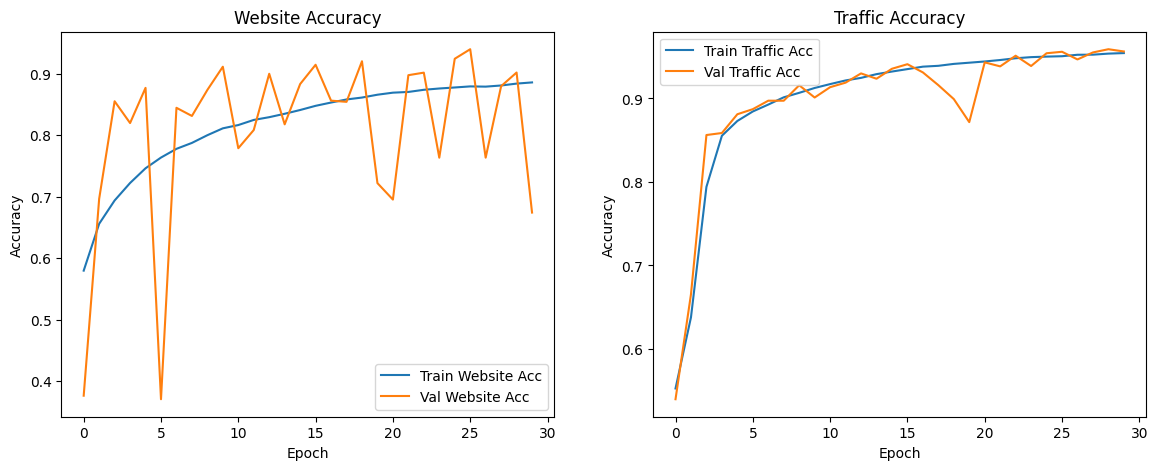

In [ ]:
# Plot for Training
import matplotlib.pyplot as plt

# Assuming your history object is named 'history'
# Plot training & validation accuracy for both outputs

plt.figure(figsize=(14,5))

# Website Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['website_output_accuracy'], label='Train Website Acc')
plt.plot(history.history['val_website_output_accuracy'], label='Val Website Acc')
plt.title('Website Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Traffic Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['traffic_output_accuracy'], label='Train Traffic Acc')
plt.plot(history.history['val_traffic_output_accuracy'], label='Val Traffic Acc')
plt.title('Traffic Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


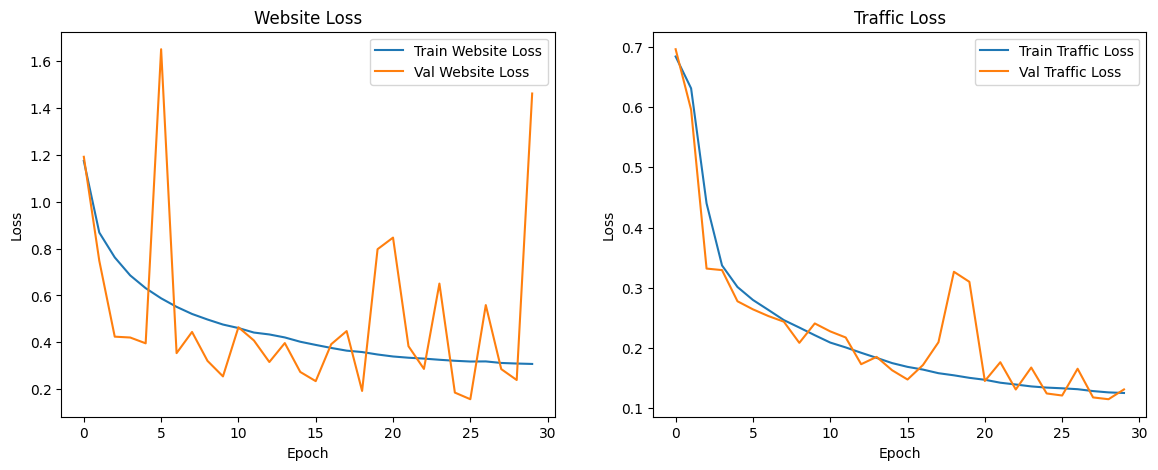

In [ ]:
# Loss Curve

plt.figure(figsize=(14,5))

# Website Loss
plt.subplot(1,2,1)
plt.plot(history.history['website_output_loss'], label='Train Website Loss')
plt.plot(history.history['val_website_output_loss'], label='Val Website Loss')
plt.title('Website Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Traffic Loss
plt.subplot(1,2,2)
plt.plot(history.history['traffic_output_loss'], label='Train Traffic Loss')
plt.plot(history.history['val_traffic_output_loss'], label='Val Traffic Loss')
plt.title('Traffic Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


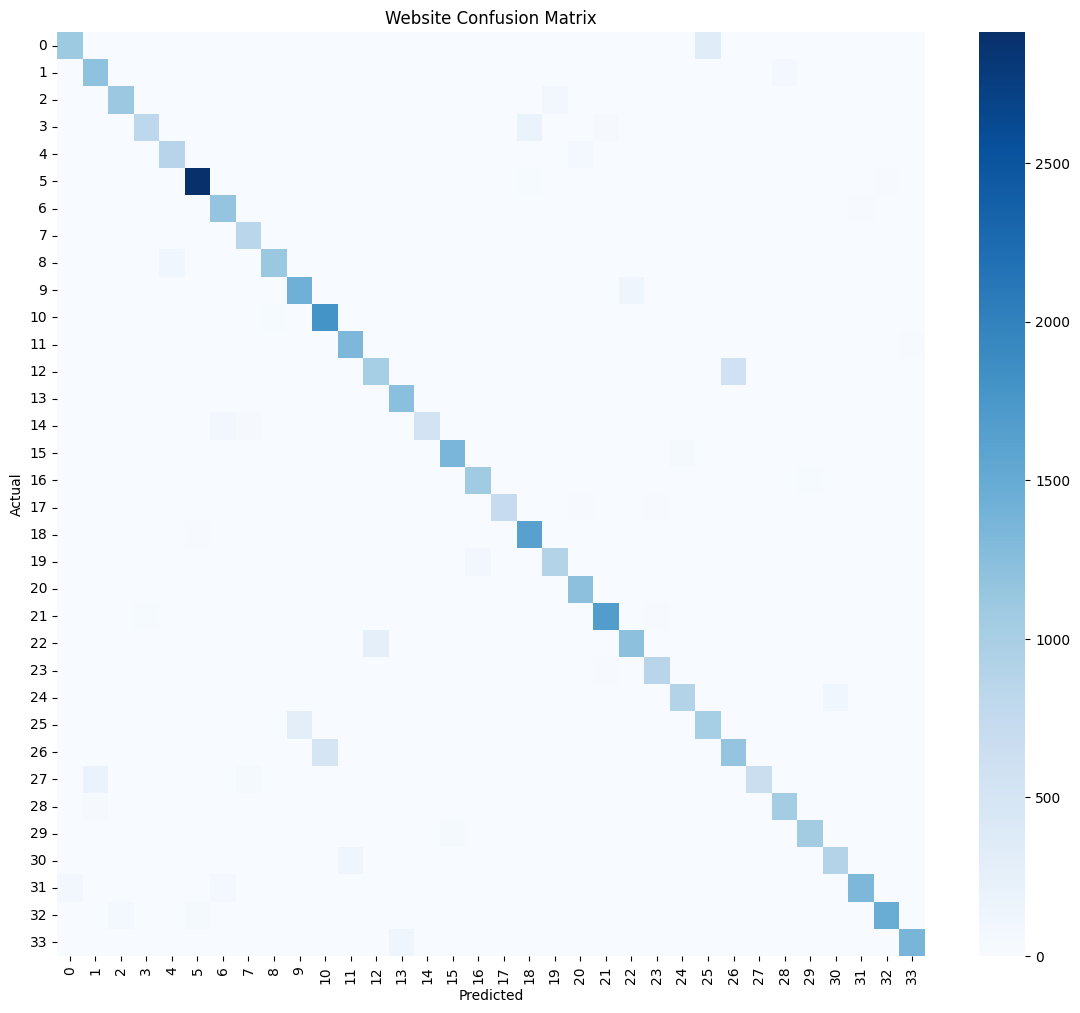

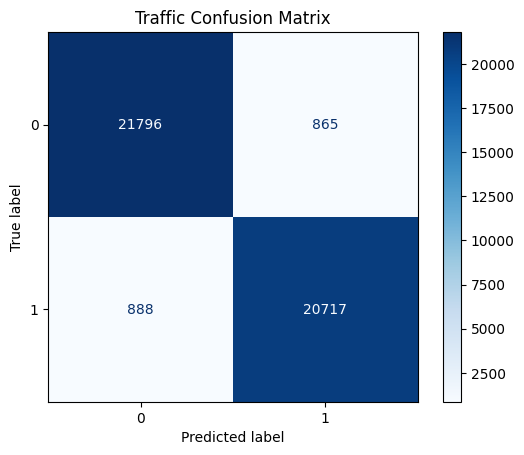

In [ ]:
# Plot for Testing

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Computing confusion matrix
cm = confusion_matrix(y_test_label, y_pred_website_labels)

plt.figure(figsize=(14, 12))  # Increase figure size
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title("Website Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Rotating labels
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()


# Traffic confusion matrix
cm_traffic = confusion_matrix(y_test_traffic, y_pred_traffic_labels)
disp_traffic = ConfusionMatrixDisplay(cm_traffic)
disp_traffic.plot(cmap=plt.cm.Blues)
plt.title("Traffic Confusion Matrix")
plt.show()


In [ ]:
predictions = model.predict(X_test, batch_size=64, verbose=1)

website_preds = np.argmax(predictions[0], axis=1)  # 34 classes
traffic_preds = np.argmax(predictions[1], axis=1)  # 2 classes

692/692 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "website_true": y_test_label,
    "website_pred": website_preds,
    "traffic_true": y_test_traffic,
    "traffic_pred": traffic_preds
})

output_csv_path = "/content/drive/MyDrive/BE_Project/prediction_results/test_predictions.csv"
df.to_csv(output_csv_path, index=False)
print(f"Predictions saved to {output_csv_path}")

website_acc = np.mean(website_preds == y_test_label)
traffic_acc = np.mean(traffic_preds == y_test_traffic)
print(f"\nManual Accuracy Check -> Website: {website_acc:.4f}, Traffic: {traffic_acc:.4f}")

Predictions saved to /content/drive/MyDrive/BE_Project/prediction_results/test_predictions.csv

Manual Accuracy Check -> Website: 0.9047, Traffic: 0.9604


# New Section